In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from torch.utils.data import DataLoader,TensorDataset

In [ ]:
import seaborn as sns
iris = sns.load_dataset('iris')

In [ ]:
# organize the data

# convert from pandas dataframe to tensor
data = torch.tensor( iris[iris.columns[0:4]].values ).float()

# transform species to number
labels = torch.zeros(len(data), dtype=torch.long)
# labels[iris.species=='setosa']   = 0 # don't need!
labels[iris.species=='versicolor'] = 1
labels[iris.species=='virginica']  = 2

# Break the data into batches

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(data,labels,test_size=.2)

train_dataset = TensorDataset(x_train,y_train)
test_dataset = TensorDataset(x_test,y_test)

train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=len(test_dataset))

In [ ]:
class theModelClass(nn.Module):
  def __init__(self,dropoutRate):
    super().__init__()

    self.input  = nn.Linear(4,12)
    self.hidden = nn.Linear(12,12)
    self.output = nn.Linear(12,3)

    self.dr = dropoutRate

  def forward(self,x):

    # input
    x = F.relu(self.input(x))
    x = F.dropout(x,p=self.dr,training=self.training)
    # hidden
    x = F.relu(self.hidden(x))
    x = F.dropout(x,p=self.dr,training=self.training)
    # output
    x = self.output(x)
    return x

In [ ]:
def createANewModel(dropoutrate,L2lambda, L1lambda):
  ANNiris = theModelClass(dropoutrate)

  lossfun = nn.CrossEntropyLoss()

  optimizer = torch.optim.SGD(ANNiris.parameters(),lr=.005,weight_decay=L2lambda)

  return ANNiris,lossfun,optimizer, L1lambda

In [ ]:
# train the model

# global parameter
numepochs = 1000

def trainTheModel(ANNiris, lossfun, optimizer, L1lambda):

  # initialize accuracies as empties
  trainAcc = []
  testAcc  = []
  losses   = []

  # loop over epochs
  for epochi in range(numepochs):
    ANNiris.train()

    # loop over training data batches
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = ANNiris(X)
      loss = lossfun(yHat,y)

      # ADD L1 regularization
      if L1lambda > 0:
          l1_norm = sum(torch.linalg.norm(p, 1) for p in ANNiris.parameters())
          loss += L1lambda * l1_norm

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # compute training accuracy just for this batch
      batchAcc.append( 100*torch.mean((torch.argmax(yHat,axis=1) == y).float()).item() )
      batchLoss.append( loss.item() )
    # end of batch loop...

    trainAcc.append( np.mean(batchAcc) )
    losses.append( np.mean(batchLoss) )

    # test accuracy
    ANNiris.eval()
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    predlabels = torch.argmax( ANNiris(X),axis=1 )
    testAcc.append( 100*torch.mean((predlabels == y).float()).item() )

  # function output
  return trainAcc,testAcc,losses

In [ ]:
# create a model
L2lambda_single = .01
dropoutrate_single = 0.2
L1lambda_single = 0.001
ANNiris,lossfun,optimizer,current_L1lambda = createANewModel(dropoutrate_single, L2lambda_single, L1lambda_single)

# train the model
trainAcc,testAcc,losses = trainTheModel(ANNiris, lossfun, optimizer, current_L1lambda)

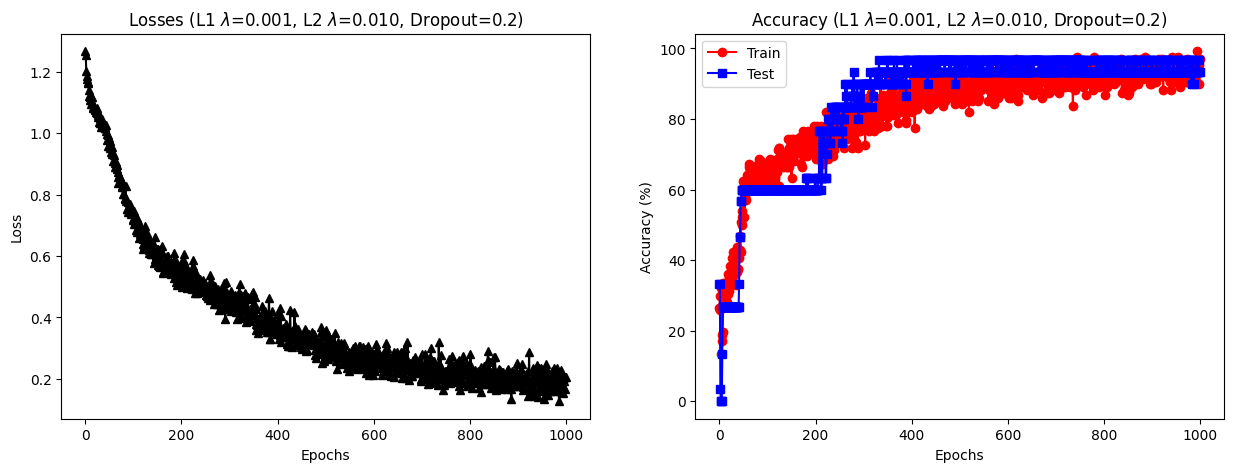

In [ ]:
# plot the results
fig,ax = plt.subplots(1,2,figsize=(15,5))


ax[0].plot(losses,'k^-')
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_title(rf'Losses (L1 $\lambda$={L1lambda_single:.3f}, L2 $\lambda$={L2lambda_single:.3f}, Dropout={dropoutrate_single})')

ax[1].plot(trainAcc,'ro-')
ax[1].plot(testAcc,'bs-')
ax[1].set_title(rf'Accuracy (L1 $\lambda$={L1lambda_single:.3f}, L2 $\lambda$={L2lambda_single:.3f}, Dropout={dropoutrate_single})')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].legend(['Train','Test'])

plt.show()

In [ ]:
# create a 1D smoothing filter
def smooth(x,k):
  return np.convolve(x,np.ones(k)/k,mode='same')

# The experiment

In [ ]:
# range of L2 regularization amounts
l2lambdas = np.linspace(0,.1,10)

# Constant dropout and L1 for this experiment
dropoutrate_exp = 0.2
L1lambda_exp = 0.001

# initialize output results matrices
accuracyResultsTrain = np.zeros((numepochs,len(l2lambdas)))
accuracyResultsTest  = np.zeros((numepochs,len(l2lambdas)))


# loop over batch sizes
for li, current_l2lambda in enumerate(l2lambdas):

  # create and train a model
  ANNiris,lossfun,optimizer,current_L1lambda = createANewModel(dropoutrate_exp, current_l2lambda, L1lambda_exp)
  trainAcc,testAcc,losses = trainTheModel(ANNiris, lossfun, optimizer, current_L1lambda)

  # store data
  accuracyResultsTrain[:,li] = smooth(trainAcc,10)
  accuracyResultsTest[:,li]  = smooth(testAcc,10)

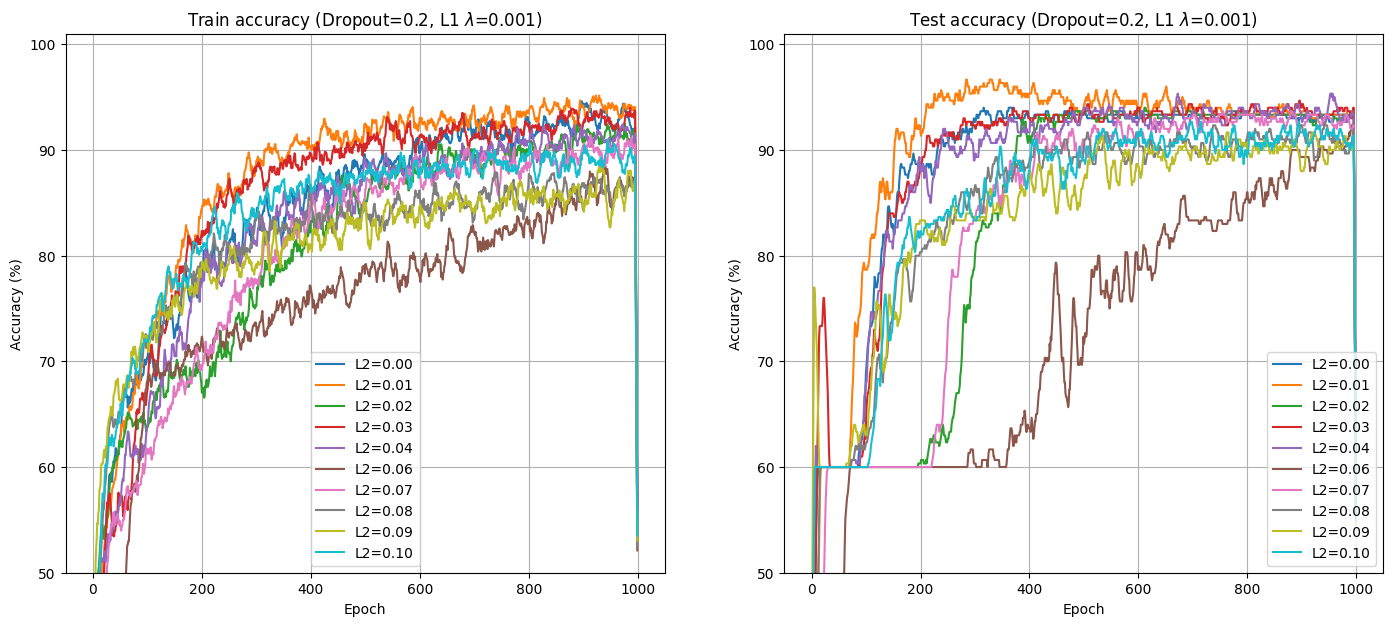

In [ ]:
# plot some results
fig,ax = plt.subplots(1,2,figsize=(17,7))

ax[0].plot(accuracyResultsTrain)
ax[0].set_title(rf'Train accuracy (Dropout={dropoutrate_exp}, L1 $\lambda$={L1lambda_exp:.3f})')
ax[1].plot(accuracyResultsTest)
ax[1].set_title(rf'Test accuracy (Dropout={dropoutrate_exp}, L1 $\lambda$={L1lambda_exp:.3f})')

# make the legend easier to read
leglabels = [f"L2={i:.2f}" for i in l2lambdas]

# common features
for i in range(2):
  ax[i].legend(leglabels)
  ax[i].set_xlabel('Epoch')
  ax[i].set_ylabel('Accuracy (%)')
  ax[i].set_ylim([50,101])
  ax[i].grid()

plt.show()